## Свёрточные нейронные сети для визуального распознавания

В этом упражнении разберем базовый конвейер классификации изображений, перекрестную проверку, а также приобретем навыки написания эффективного векторизованного кода.

In [1]:
# Настраиваем логгер, вывод графиков
import gc
import logging
import matplotlib.pyplot as plt

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

plt.rcParams['figure.figsize'] = (10.0, 8.0) # размер в дюймах по умолчанию (1000х800 px)
plt.rcParams['image.interpolation'] = 'nearest' # отключаем сглаживание, мыло
plt.rcParams['image.cmap'] = 'gray' # для отображения одноканальынх изображений

>1. Заменил try/except на globals и gc.collect()
>2. Добавил assert (для отладки и разработки)
>3. Подключил psutil, создал log_memory_usage
>4. Проверка shape[0]
---

## Датасет CIFAR-10
Сбалансированный датасет — это выборка, в которой каждого класса объектов присутствует одинаковое количество (или почти одинаковое).

- В **CIFAR-10** ровно 50 000 картинок и 10 классов. Каждому классу (кошкам, машинам, самолетам) принадлежит ровно по 5 000 картинок. Датасет идеально сбалансирован.  

- Если бы у вас было 45 000 картинок собак и всего 500 картинок кошек, такой датасет назывался бы **несбалансированным** (imbalanced). Обучать модели на несбалансированных данных опасно: ИИ станет «ленивым», начнет везде угадывать только собак и получать высокую точность, полностью игнорируя редких кошек.

In [2]:
from data_utils import load_and_validate_cifar10

cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'

# Очистка памяти если уже запускалось
if 'X_train' in globals():
   del X_train, y_train, X_test, y_test
   gc.collect()

X_train, y_train, X_test, y_test = load_and_validate_cifar10(cifar10_dir)

logging.info(f"X_train: {X_train.shape}")
logging.info(f"y_train метки (0-9): {y_train.shape}")
logging.info(f"X_test: {X_test.shape}")
logging.info(f"y_test: {y_test.shape}")

2026-09-03 22:13:10,260 - INFO - Starting CIFAR-10 loading pipeline, Current RAM: 103.02 MB
2026-09-03 22:13:11,039 - INFO - Data loaded into RAM. Current RAM: 1511.36 MB
2026-09-03 22:13:11,040 - INFO - Data validation successful. Shapes: Train (50000, 32, 32, 3), Test (10000, 32, 32, 3)
2026-09-03 22:13:11,040 - INFO - X_train: (50000, 32, 32, 3)
2026-09-03 22:13:11,041 - INFO - y_train метки (0-9): (50000,)
2026-09-03 22:13:11,041 - INFO - X_test: (10000, 32, 32, 3)
2026-09-03 22:13:11,041 - INFO - y_test: (10000,)


---
---

> Оптимизация если будет 5000000 картинок и меток:  

Способ 1. Использование встроенных итераторов (Lazy Evaluation)  

- Например, в PyTorch вы просто создаете DataLoader со случайным сэмплером, и он сам достает вам нужные 7 штук, не сканируя весь датасет целиком:


In [ ]:
train_loader = DataLoader(dataset, batch_size=7, shuffle=True)  
images, labels = next(iter(train_loader))


Способ 2. Предварительная индексация (Группировка)  

Если вам нужно часто визуализировать или сэмплировать данные из 5-миллионного датасета, операцию поиска индексов делают всего один раз при загрузке данных, создавая поисковый индекс (инвертированный индекс):

In [ ]:
from collections import defaultdict

# 1. Один раз пробегаем по датасету и раскладываем индексы по полочкам
# Это занимает время, но делается ЕДИНОЖДЫ
class_to_idxs = defaultdict(list)
for idx, label in enumerate(y_train):
    class_to_idxs[label].append(idx)

# 2. Теперь выборка 7 картинок для любого класса происходит МГНОВЕННО:
# Мы не сканируем 5 000 000 строк, а сразу берем готовый список нужного класса
idxs = np.random.choice(class_to_idxs[target_class], 7, replace=False)


Способ 3. Метод случайного тыка (Rejection Sampling)

Если память жестко ограничена, используют алгоритмы вероятностного сэмплинга. Компьютер просто генерирует случайный индекс от 0 до 5 000 000, смотрит на класс картинки, и если он совпал с нужным — забирает её в корзину. Как только в корзине набралось 7 штук — алгоритм останавливается. На огромных данных это работает быстрее, чем сканирование всего массива.  

Если у нас 10 классов и каждого ровно по 10%, то вероятность с первого раза угадать нужный класс равна 0.1. Чтобы найти 7 картинок, вам в среднем понадобится около 70 случайных проверок. На фоне 5 000 000 строк это мгновенно!

---
---
>Продолжаем

### Визуализируем наш датасет небольшим куском

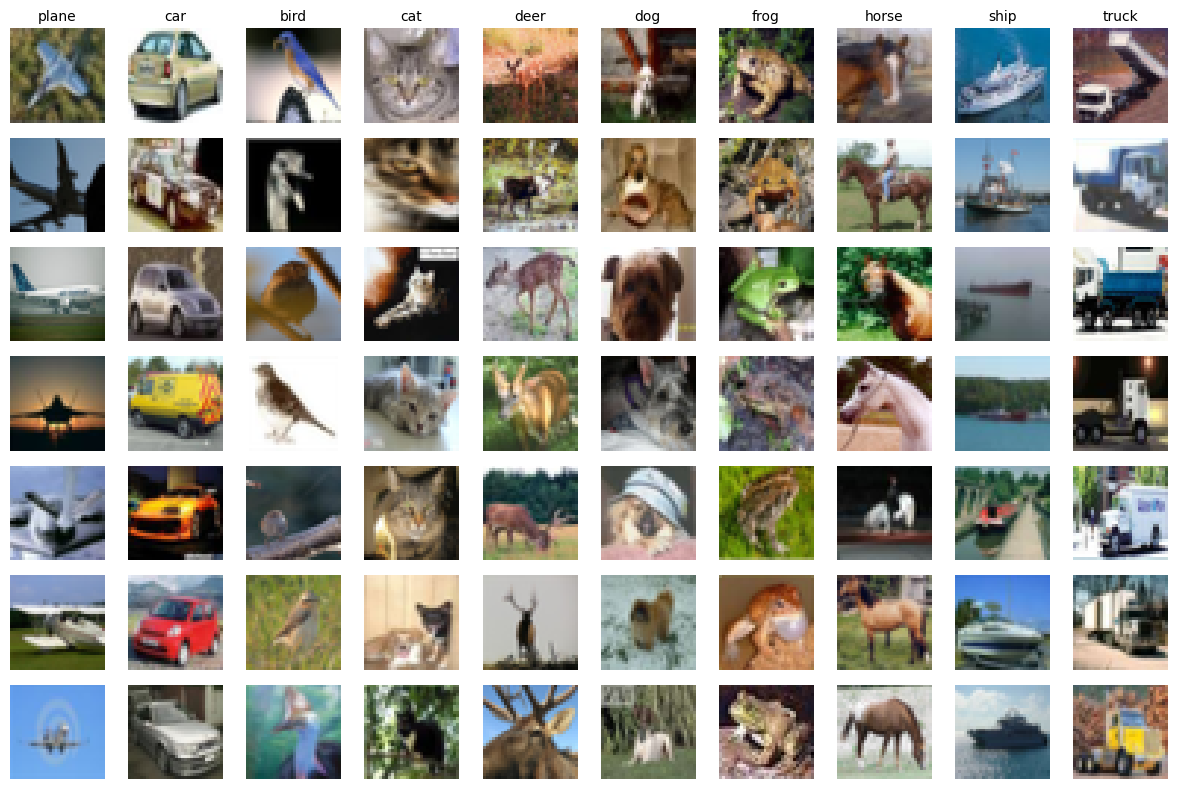

In [3]:
import numpy as np

classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7

# Используем современный RNG для воспроизводимости
rng = np.random.default_rng(seed=42)

# Создаем сразу всю сетку осей (Axes) и задаем размер фигуры
fig, axes = plt.subplots(
    nrows=samples_per_class, 
    ncols=num_classes, 
    figsize=(12, 8)
)

for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    selected_idxs = rng.choice(idxs, size=samples_per_class, replace=False)

    for i, idx in enumerate(selected_idxs):
        ax = axes[i, y]
        ax.imshow(X_train[idx].astype('uint8'))
        ax.axis('off')
        if i == 0:
            ax.set_title(cls, fontsize=10)

plt.tight_layout()
plt.show()

---
---

>Как NumPy управляет памятью?

#### Basic Indexing (Срезы / Slices)

`X_train[:5000]`

- **Как это работает:** Всегда возвращает **View** (представление). Память не выделяется, данные не копируются. Это работает за O(1).  

- **Что происходит в памяти:** Новый массив просто ссылается на тот же самый кусок памяти, где лежат исходные 50 000 картинок, но указывает процессору: _«читай только от 0 до 5000»_.  
>При изменении элементов оригинальный массив X_train тоже изменится!!!

In [4]:
sub_array = X_train[:5000]
sub_array[0] = 255  # Изменили пиксель в подмассиве

#### Advanced / Fancy Indexing (Маски и списки)

`X_train[mask]`

- **Как это работает:** Всегда возвращает **Copy** (копию). Память выделяется заново, данные физически копируются в новый буфер.  

- **Почему так происходит:** Элементы в `mask` (список или массив индексов) не обязательно должны идти по порядку. Например `mask = [10, 0, 500, 3]` - NumPy физически не может сделать View для разрозненных индексов. Ему приходится выделить в оперативной памяти **новый чистый буфер** и скопировать туда пиксели выбранных картинок один за другим.  
  
>Оригинальный массив X_train останется нетронутым, потому что вы изменили изолированную копию в памяти.

In [ ]:
sub_array = X_train[[10, 0, 500, 3]]
sub_array[0] = 255  # Изменили пиксель в подмассиве

---
---

>Продолжаем

In [5]:
# Берем 4500 обучающих и 500 тестовых картинок для простоты эксперемента вместо 45000 и 5000

num_training = 5000
X_train = X_train[:num_training]
y_train = y_train[:num_training]

num_test = 500
X_test = X_test[:num_test]
y_test = y_test[:num_test]

#### Уплощение тензора (Flattening)  
Это «сплющивание» несколько пространственных размерностей картинок в одну плоскую строку (4-мерный массив в 2-мерный), оставляя нетронутым размер батча, выстраивая все пиксели в один ряд, делая их признаками для формулы матричного умножения Y = X * W + b.

Также применяется при построении нейросети, в самом её конце всегда стоят обычные полносвязные (`Dense` или `Linear`) слои, которые выдают итоговый ответ (например, вероятность класса). Эти слои, как и классические модели, умеют работать только с плоскими векторами признаков. Поэтому перед тем, как передать данные на выходной слой, их обязательно «плющат» из 4D в 2D.

>В PyTorch за это отвечает слой nn.Flatten()

>В NumPy **np.reshape(array, newshape)**: Универсальный инструмент, позволяет превратить 4D в 2D и обратно 2D в 4D массива без изменения его содержимого в памяти. Почти всегда возвращает View, стоит O(1).


In [6]:
# -1? если завтра разрешение картинок изменится (например, станет 64x64), код с -1 не придется переписывать — он посчитает всё сам!

X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
print(X_train.shape, X_test.shape) 
# (5000, 3072) сплющили в 2D
# (500, 3072)  сплющили в 2D

(5000, 3072) (500, 3072)


#### Почему для нейросети (CNN) требуется 4D для инференса и 2D в самом конце для ответа?  

В плоской строке пиксель №28 и пиксель №29 в исходной картинке находились друг под другом (это вертикальная линия). Но после **reshape** - они оказываются в разных концах длинного вектора.

- **CNN** ищет паттерны (глаза, углы, линии), сканируя картинку маленьким окошком (фильтром) 3х3 или 5х5 пикселей. Он «смотрит» на пиксель и одновременно видит его соседей: слева, справа, сверху и снизу. Благодаря этому сеть понимает геометрию: «Ага, тут линия идет по диагонали, значит это край уха». *В плоском векторе понятия «сверху» и «снизу» исчезают.*

Проблема инвариантности к сдвигу (Spatial Invariance)

- Если кошка на фото сдвинется на 5 пикселей вправо в плоском векторе, все 784 значения полностью перемешаются, и обычной модели придется учиться распознавать кошку заново.

Работа с цветом (Channels)

- **CNN** анализирует взаимосвязь цветов в каждой конкретной точке (например, смешение каналов дает нужный оттенок кожи или листвы).
- Каналы вытягиваются друг за другом (сначала весь красный слой картинки, потом весь зеленый, потом синий). Информация о том, какие три цвета принадлежали конкретной точке, полностью уничтожается.

💡 Когда сеть уже извлекла все двумерные признаки и готова выдать итоговый ответ (например, "это кошка") - делаем reshape обратно в 2D для понятного ответа человеку.

Таким образом, архитектура классической сверточной сети всегда делится на два этапа:

---

>Продолжаем

#### Пробуем обучить с помощью k-NN метода

|Этап|Нейросеть (CNN)|k-NN|
|---|---|---|
|**Обучение (`.train`)**|Очень медленно (часы/дни)|**Мгновенно (\(O(1)\))**|
|**Предсказание (`.predict`)**|**Мгновенно (\(O(1)\) на инференс)**|Очень медленно (\(O(N)\) на каждый тест)|
|**Память на диске/в ОЗУ**|Маленькая (только веса модели)|**Огромная** (нужно вечно хранить весь датасет)|

In [7]:
# Настройка системы (для старых Python)
import sys
import types

# Создаем виртуальные модули прямо в оперативной памяти
past_module = types.ModuleType("past")
past_builtins = types.ModuleType("past.builtins")

# Приравниваем устаревший xrange к стандартному range из Python 3
past_builtins.xrange = range  

# Регистрируем обманку в системе
sys.modules["past"] = past_module
sys.modules["past.builtins"] = past_builtins

print("Виртуальная заплатка успешно поставлена! Ошибки 'past' больше не будет.")


Виртуальная заплатка успешно поставлена! Ошибки 'past' больше не будет.


In [8]:
from cs231n.classifiers import KNearestNeighbor

# Create a kNN classifier instance.
# Remember that training a kNN classifier is a noop (пустая операция):
# the Classifier simply remembers the data and does no further processing
classifier = KNearestNeighbor()
classifier.train(X_train, y_train) # загружаем датасеты в память

In [9]:
# Проверяем, что классификатор запомнил формы наших тренировочных матриц
print("Форма сохраненных картинок:", classifier.X_train.shape)
print("Форма сохраненных меток классов:", classifier.y_train.shape)

Форма сохраненных картинок: (5000, 3072)
Форма сохраненных меток классов: (5000,)


We would now like to classify the test data with the kNN classifier. Recall that we can break down this process into two steps:

1. First we must compute the distances between all test examples and all train examples.
2. Given these distances, for each test example we find the k nearest examples and have them vote for the label

Lets begin with computing the distance matrix between all training and test examples. For example, if there are **Ntr** training examples and **Nte** test examples, this stage should result in a **Nte x Ntr** matrix where each element (i,j) is the distance between the i-th test and j-th train example.

**Note: For the three distance computations that we require you to implement in this notebook, you may not use the np.linalg.norm() function that numpy provides.**

First, open `cs231n/classifiers/k_nearest_neighbor.py` and implement the function `compute_distances_two_loops` that uses a (very inefficient) double loop over all pairs of (test, train) examples and computes the distance matrix one element at a time.

Вычисляем расстояния (Инференс)

In [10]:
# Open cs231n/classifiers/k_nearest_neighbor.py and implement
# compute_distances_two_loops.

# Test your implementation:
dists = classifier.compute_distances_two_loops(X_test)
print(dists.shape)

(500, 5000)


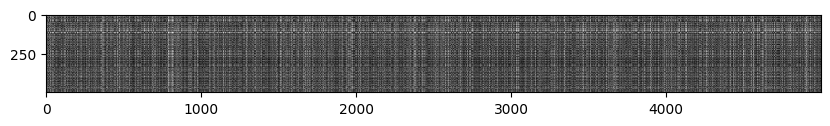

In [11]:
# We can visualize the distance matrix: each row is a single test example and
# its distances to training examples
plt.imshow(dists, interpolation='none')
plt.show()

**Inline Question 1**

Notice the structured patterns in the distance matrix, where some rows or columns are visibly brighter. (Note that with the default color scheme black indicates low distances while white indicates high distances.)

- What in the data is the cause behind the distinctly bright rows?
- What causes the columns?

$\color{blue}{\textit Your Answer:}$ Cause behind the distinctly bright rows: A distinctly bright row indicates that a specific test image has a very high pixel-wise L2 distance to almost all images in the training dataset. This happens when the test image is a statistical outlier compared to the training data—for instance, if it has a completely different background color palette (e.g., a bright white airplane against a clear sky) or extreme brightness/contrast compared to the typical training images (e.g., mostly green backgrounds of animals on grass).Cause behind the columns:A distinctly bright column indicates that a specific training image has a very high L2 distance to almost all images in the test dataset. This is caused by an unusual or anomalous image in the training set (e.g., a completely dark/black frame, a heavily overexposed photo, or a unique color scheme) that does not match the visual distribution of any test examples, making it consistently "far" from everything else.



Для случайного угадывания в CIFAR-10 (где 10 классов) точность составляет всего 10%.   
k-NN работает почти в 3 раза лучше случайного тыка (27%)

In [12]:
# Now implement the function predict_labels and run the code below:
# We use k = 1 (which is Nearest Neighbor).
y_test_pred = classifier.predict_labels(dists, k=1)

# Compute and print the fraction of correctly predicted examples
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (num_correct, num_test, accuracy))

Got 137 / 500 correct => accuracy: 0.274000


You should expect to see approximately `27%` accuracy. Now lets try out a larger `k`, say `k = 5`:

In [13]:
y_test_pred = classifier.predict_labels(dists, k=5)
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (num_correct, num_test, accuracy))

Got 139 / 500 correct => accuracy: 0.278000


You should expect to see a slightly better performance than with `k = 1`.

Попиксельное Евклидово расстояние (L2) — это очень слабый способ сравнения картинок. Если сдвинуть кота на 2 пикселя вбок, его L2-расстояние до самого себя будет огромным, хотя для человека картинка не изменилась.

**Inline Question 2**

We can also use other distance metrics such as L1 distance.
For pixel values $p_{ij}^{(k)}$ at location $(i,j)$ of some image $I_k$,

the mean $\mu$ across all pixels over all images is $$\mu=\frac{1}{nhw}\sum_{k=1}^n\sum_{i=1}^{h}\sum_{j=1}^{w}p_{ij}^{(k)}$$
And the pixel-wise mean $\mu_{ij}$ across all images is
$$\mu_{ij}=\frac{1}{n}\sum_{k=1}^np_{ij}^{(k)}.$$
The general standard deviation $\sigma$ and pixel-wise standard deviation $\sigma_{ij}$ is defined similarly.

Which of the following preprocessing steps will not change the performance of a Nearest Neighbor classifier that uses L1 distance? Select all that apply. To clarify, both training and test examples are preprocessed in the same way.

1. Subtracting the mean $\mu$ ($\tilde{p}_{ij}^{(k)}=p_{ij}^{(k)}-\mu$.)
2. Subtracting the per pixel mean $\mu_{ij}$  ($\tilde{p}_{ij}^{(k)}=p_{ij}^{(k)}-\mu_{ij}$.)
3. Subtracting the mean $\mu$ and dividing by the standard deviation $\sigma$.
4. Subtracting the pixel-wise mean $\mu_{ij}$ and dividing by the pixel-wise standard deviation $\sigma_{ij}$.
5. Rotating the coordinate axes of the data, which means rotating all the images by the same angle. Empty regions in the image caused by rotation are padded with a same pixel value and no interpolation is performed.

$\color{blue}{\textit Your Answer:}$ Correct choices: 1 and 3.


$\color{blue}{\textit Your Explanation:}$
- Options 1 and 2 represent translations (shifting the data). In L1 distance, subtracting a constant (whether it is a global scalar $\mu$ or a pixel-specific value $\mu_{ij}$) from both the training and testing images cancels out completely during subtraction: |(x - mean) - (y - mean)| = |x - y|. Since the absolute distances between all images remain identical, the classifier's performance does not change.
- Option 3 scales the entire feature space uniformly by a positive constant ($1/\sigma$). This rescales all pairwise distances by the same factor, preserving their relative order (ranking). Therefore, the nearest neighbor for any test point remains exactly the same.
- Option 4 applies different scaling factors ($\sigma_{ij}$) to different pixel dimensions, which distorts the distance ratios between images and changes the nearest neighbors.
- Option 5 rotates the data. Unlike L2 distance, L1 (Manhattan) distance depends heavily on the orientation of the coordinate axes, so rotating the data alters the distance values and the performance.


In [14]:
# Now lets speed up distance matrix computation by using partial vectorization
# with one loop. Implement the function compute_distances_one_loop and run the
# code below:
dists_one = classifier.compute_distances_one_loop(X_test)

# To ensure that our vectorized implementation is correct, we make sure that it
# agrees with the naive implementation. There are many ways to decide whether
# two matrices are similar; one of the simplest is the Frobenius norm. In case
# you haven't seen it before, the Frobenius norm of two matrices is the square
# root of the squared sum of differences of all elements; in other words, reshape
# the matrices into vectors and compute the Euclidean distance between them.
difference = np.linalg.norm(dists - dists_one, ord='fro')
print('One loop difference was: %f' % (difference, ))
if difference < 0.001:
    print('Good! The distance matrices are the same')
else:
    print('Uh-oh! The distance matrices are different')

One loop difference was: 0.000000
Good! The distance matrices are the same


In [15]:
# Now implement the fully vectorized version inside compute_distances_no_loops
# and run the code
dists_two = classifier.compute_distances_no_loops(X_test)

# check that the distance matrix agrees with the one we computed before:
difference = np.linalg.norm(dists - dists_two, ord='fro')
print('No loop difference was: %f' % (difference, ))
if difference < 0.001:
    print('Good! The distance matrices are the same')
else:
    print('Uh-oh! The distance matrices are different')

No loop difference was: 0.000000
Good! The distance matrices are the same


In [16]:
# Let's compare how fast the implementations are
def time_function(f, *args):
    """
    Call a function f with args and return the time (in seconds) that it took to execute.
    """
    import time
    tic = time.time()
    f(*args)
    toc = time.time()
    return toc - tic

two_loop_time = time_function(classifier.compute_distances_two_loops, X_test)
print('Two loop version took %f seconds' % two_loop_time)

one_loop_time = time_function(classifier.compute_distances_one_loop, X_test)
print('One loop version took %f seconds' % one_loop_time)

no_loop_time = time_function(classifier.compute_distances_no_loops, X_test)
print('No loop version took %f seconds' % no_loop_time)

# You should see significantly faster performance with the fully vectorized implementation!

# NOTE: depending on what machine you're using,
# you might not see a speedup when you go from two loops to one loop,
# and might even see a slow-down.

Two loop version took 10.362835 seconds
One loop version took 29.753995 seconds
No loop version took 0.092511 seconds


>Магия BLAS: Функция np.dot под капотом (no loop) использует низкоуровневые Си-библиотеки линейной алгебры. Они умеют разбивать матрицы на идеальные блоки, загружать их в регистры процессора и задействовать SIMD-инструкции (параллельные вычисления на уровне ядер CPU).

### Cross-validation

We have implemented the k-Nearest Neighbor classifier but we set the value k = 5 arbitrarily. We will now determine the best value of this hyperparameter with cross-validation.

In [17]:
num_folds = 5
k_choices = [1, 3, 5, 8, 10, 12, 15, 20, 50, 100]

X_train_folds = []
y_train_folds = []

# np.array_split делит массив на N примерно равных частей и возвращает список массивов
X_train_folds = np.array_split(X_train, num_folds)
y_train_folds = np.array_split(y_train, num_folds)

# Словарь для хранения точности для разных значений k
k_to_accuracies = {}


################################################################################
# TODO: Выполнить k-fold кросс-валидацию.
################################################################################
for k in k_choices:
    # Инициализируем пустой список для точностей под текущее значение k
    k_to_accuracies[k] = []
    
    for i in range(num_folds):
        # 1. Формируем валидационный фолд (текущий i-й фолд)
        X_val_fold = X_train_folds[i]
        y_val_fold = y_train_folds[i]
        
        # 2. Собираем обучающие фолды (все фолды, кроме i-го)
        # Берем все фолды ДО i и все фолды ПОСЛЕ i, объединяем их списки
        X_train_fold_parts = X_train_folds[:i] + X_train_folds[i+1:]
        y_train_fold_parts = y_train_folds[:i] + y_train_folds[i+1:]
        
        # np.concatenate склеивает список матриц обратно в одну большую матрицу
        X_train_fold_cur = np.concatenate(X_train_fold_parts, axis=0)
        y_train_fold_cur = np.concatenate(y_train_fold_parts, axis=0)
        
        # 3. Инициализируем классификатор и обучаем его на склеенных фолдах
        classifier = KNearestNeighbor()
        classifier.train(X_train_fold_cur, y_train_fold_cur)
        
        # 4. Считаем матрицу расстояний без циклов для валидационного фолда
        dists = classifier.compute_distances_no_loops(X_val_fold)
        
        # 5. Делаем предсказания классов
        y_val_pred = classifier.predict_labels(dists, k=k)
        
        # 6. Считаем точность (accuracy) на текущем фолде
        # Сравниваем предсказания с истиной, считаем долю совпадений
        num_correct = np.sum(y_val_pred == y_val_fold)
        accuracy = float(num_correct) / len(y_val_fold)
        
        # Сохраняем полученную точность в словарь
        k_to_accuracies[k].append(accuracy)


# Печать результатов
for k in sorted(k_to_accuracies):
    for accuracy in k_to_accuracies[k]:
        print('k = %d, accuracy = %f' % (k, accuracy))

k = 1, accuracy = 0.262000
k = 1, accuracy = 0.257000
k = 1, accuracy = 0.264000
k = 1, accuracy = 0.278000
k = 1, accuracy = 0.265000
k = 3, accuracy = 0.238000
k = 3, accuracy = 0.249000
k = 3, accuracy = 0.240000
k = 3, accuracy = 0.266000
k = 3, accuracy = 0.255000
k = 5, accuracy = 0.248000
k = 5, accuracy = 0.266000
k = 5, accuracy = 0.280000
k = 5, accuracy = 0.292000
k = 5, accuracy = 0.280000
k = 8, accuracy = 0.262000
k = 8, accuracy = 0.282000
k = 8, accuracy = 0.273000
k = 8, accuracy = 0.290000
k = 8, accuracy = 0.274000
k = 10, accuracy = 0.265000
k = 10, accuracy = 0.296000
k = 10, accuracy = 0.276000
k = 10, accuracy = 0.284000
k = 10, accuracy = 0.282000
k = 12, accuracy = 0.260000
k = 12, accuracy = 0.295000
k = 12, accuracy = 0.279000
k = 12, accuracy = 0.283000
k = 12, accuracy = 0.280000
k = 15, accuracy = 0.252000
k = 15, accuracy = 0.289000
k = 15, accuracy = 0.278000
k = 15, accuracy = 0.282000
k = 15, accuracy = 0.274000
k = 20, accuracy = 0.270000
k = 20, accu

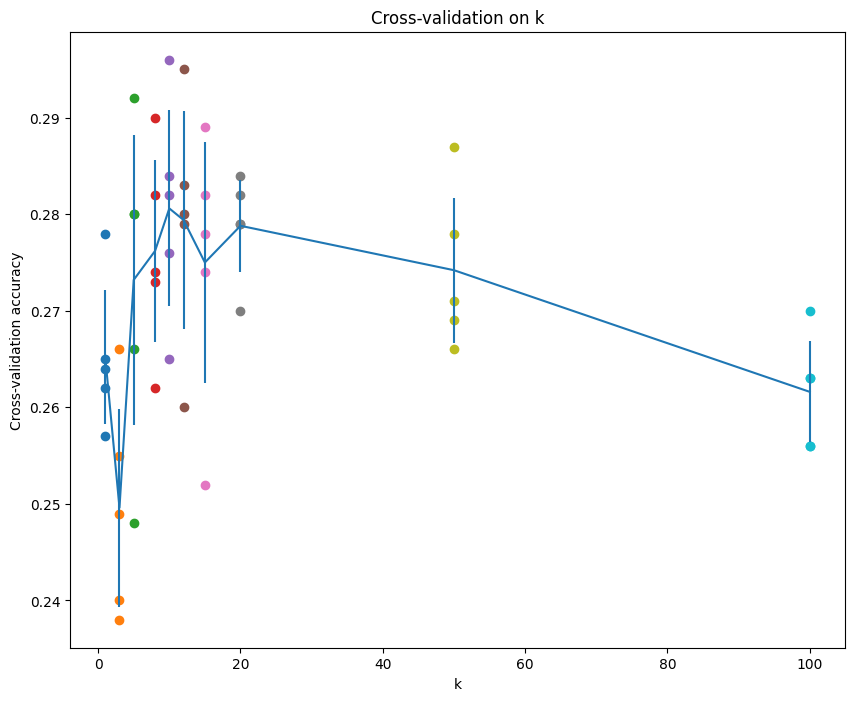

In [18]:
# plot the raw observations
for k in k_choices:
    accuracies = k_to_accuracies[k]
    plt.scatter([k] * len(accuracies), accuracies)

# plot the trend line with error bars that correspond to standard deviation
accuracies_mean = np.array([np.mean(v) for k,v in sorted(k_to_accuracies.items())])
accuracies_std = np.array([np.std(v) for k,v in sorted(k_to_accuracies.items())])
plt.errorbar(k_choices, accuracies_mean, yerr=accuracies_std)
plt.title('Cross-validation on k')
plt.xlabel('k')
plt.ylabel('Cross-validation accuracy')
plt.show()

In [19]:
# Based on the cross-validation results above, choose the best value for k,
# retrain the classifier using all the training data, and test it on the test
# data. You should be able to get above 28% accuracy on the test data.
best_k = 1

classifier = KNearestNeighbor()
classifier.train(X_train, y_train)
y_test_pred = classifier.predict(X_test, k=best_k)

# Compute and display the accuracy
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (num_correct, num_test, accuracy))

Got 137 / 500 correct => accuracy: 0.274000


**Inline Question 3**

Which of the following statements about $k$-Nearest Neighbor ($k$-NN) are true in a classification setting, and for all $k$? Select all that apply.
1. The decision boundary of the k-NN classifier is linear.
2. The training error of a 1-NN will always be lower than or equal to that of 5-NN.
3. The test error of a 1-NN will always be lower than that of a 5-NN.
4. The time needed to classify a test example with the k-NN classifier grows with the size of the training set.
5. None of the above.

$\color{blue}{\textit Your Answer:}$ 2 и 4


$\color{blue}{\textit Your Explanation:}$  

1. Ложно. Разделяющая граница \(k\)-NN является нелинейной и кусочно-постоянной (она состоит из сложных многоугольников — диаграмм Вороного). Форма границы полностью подстраивается под геометрию расположения точек в пространстве и может быть сколь угодно сложной, в отличие от линейных классификаторов (например, SVM или логистической регрессии).  

2. Истинно. При работе на обучающей выборке (\(1\)-NN) алгоритм ищет ближайшего соседа для точки из этой же выборки. Самым близким соседом для любой точки из трейна окажется она сама (расстояние до себя равно 0). Соответственно, модель всегда безошибочно назовет её истинный класс, и ошибка обучения (\(1\)-NN) будет равна ровно 0%. Для \(5\)-NN ошибка может быть выше нуля, если вокруг точки находятся 3 или более соседей другого класса.  

3. Ложно. На тестовых данных \(1\)-NN очень часто проигрывает \(5\)-NN из-за переобучения (overfitting). Модель \(1\)-NN крайне чувствительна к шуму и случайным выбросам в данных. Увеличение \(k\) до 5 сглаживает эти шумы за счет эффекта усреднения (голосования большинства), что обычно улучшает обобщающую способность модели на тесте.  

4. Истинно. Классификатор \(k\)-NN является «ленивым» алгоритмом (lazy learner). На этапе обучения он ничего не вычисляет, а просто запоминает базу данных. Вся тяжелая работа происходит на этапе тестирования: чтобы классифицировать всего один новый объект, компьютер обязан посчитать расстояния до всех \(N\) объектов из обучающего набора. Чем больше тренировочная выборка (\(N\)), тем больше вычислений (\(O(N)\)) требуется для каждого теста.

